In [1]:
import pandas as pd
import numpyro
numpyro.set_host_device_count(8)
numpyro.enable_x64()

In [2]:
df = pd.read_csv("data/cleaned_data.csv").set_index("date")
df

,number,winners,page,pédantix,pedantix,cémantix,cemantix,is_holiday
date,,,,,,,,
2022-05-14,1,4398,Affaire Dreyfus,0.0,3.0,8.0,73.0,False
2022-05-15,2,6632,Nestlé,0.0,6.0,7.0,56.0,False
2022-05-16,3,9224,Formation et évolution du Système solaire,0.0,6.0,12.0,69.0,False
2022-05-17,4,13865,Strasbourg,3.0,8.0,12.0,66.0,False
2022-05-18,5,11130,Processeur,4.0,12.0,12.0,65.0,False
...,...,...,...,...,...,...,...,...
2025-11-04,1271,33282,Premier Empire bulgare,16.0,23.0,31.0,95.0,False
2025-11-05,1272,36303,Violon,13.0,19.0,30.0,95.0,False
2025-11-06,1273,38471,Fée,16.0,24.0,27.0,90.0,False


In [3]:
df.index = pd.to_datetime(df.index)
fig = df["winners"].resample("W").sum().plot(y=["winners"], backend="plotly")
fig.update_layout(
    title="Total completions",
    legend_title_text="Weekday",
)

In [4]:
fig = df.plot(y=["pedantix", "pédantix", "cémantix", "cemantix"], backend="plotly")
fig.update_layout(
    title="Trends exploration",
    legend_title_text="Weekday",
)

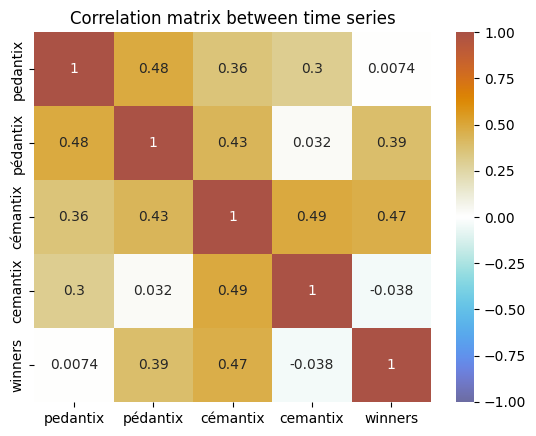

In [5]:
import seaborn as sns
import cmasher as cmr
import matplotlib.pyplot as plt

sns.heatmap(
    df[["pedantix", "pédantix", "cémantix", "cemantix", "winners"]].corr(method="spearman"),
    cmap=cmr.prinsenvlag_r, vmin=-1, vmax=1, annot=True
)

plt.title("Correlation matrix between time series");

In [6]:
cols = ["winners", "pédantix", "cémantix", "pedantix", "cemantix"]

x = df[cols].apply(pd.to_numeric, errors="coerce")
x.index = pd.to_datetime(x.index)

# Weekly mean (weeks end on Sunday by default; labels at the right edge)
weekly = x.resample("W").mean()

# Z-score per column on the weekly series
z_weekly = (weekly - weekly.mean()) / weekly.std(ddof=0)

fig = z_weekly.plot(backend="plotly")

fig.update_layout(
    title="Z-score normalized plots",
    legend_title_text="Weekday",
)

In [20]:
import pandas as pd
import plotly.express as px
import cmasher as cmr
from matplotlib.colors import to_hex  # to convert cmasher RGB -> hex for Plotly

df = df.copy()
df.index = pd.to_datetime(df.index)

weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df["weekday"] = pd.Categorical(df.index.day_name(), categories=weekday_order, ordered=True)

df_long = (
    df.reset_index(names="Time")
      .melt(
          id_vars=["Time", "weekday", "is_holiday"],
          value_vars=["pédantix", "cémantix"],
          var_name="term",
          value_name="value"
      )
)

In [21]:
colors = [to_hex(c) for c in cmr.take_cmap_colors(cmr.neon, 7)]

fig = px.histogram(
    df_long[df_long["is_holiday"]],
    x="value",
    color="weekday",
    facet_col="term",
    barmode="overlay",
    opacity=0.45,
    histnorm="probability density",
    category_orders={"weekday": weekday_order, "term": ["pédantix", "cémantix"]},
    color_discrete_sequence=colors,
)

fig.update_traces(xbins=dict(start=0, end=100, size=1))

fig.update_xaxes(range=[0, 33])
fig.update_yaxes(range=[0, 0.4])
fig.update_layout(
    width=950, height=360,
    bargap=0.05,
    title="Histograms by weekday",
    legend_title_text="Weekday",
)

fig.show()

In [23]:
fig = px.histogram(
    df_long[~df_long["is_holiday"]],
    x="value",
    color="weekday",
    facet_col="term",
    barmode="overlay",
    opacity=0.45,
    histnorm="probability density",
    category_orders={"weekday": weekday_order, "term": ["pédantix", "cémantix"]},
    color_discrete_sequence=colors,
)

fig.update_traces(xbins=dict(start=0, end=100, size=1))

fig.update_xaxes(range=[0, 33])
fig.update_yaxes(range=[0, 0.4])
fig.update_layout(
    width=950, height=360,
    bargap=0.05,
    title="Histograms by weekday",
    legend_title_text="Weekday",
)

fig.show()

In [19]:
df_long

,Time,weekday,term,value
0,2022-05-14,Saturday,pédantix,0.0
1,2022-05-15,Sunday,pédantix,0.0
2,2022-05-16,Monday,pédantix,0.0
3,2022-05-17,Tuesday,pédantix,3.0
4,2022-05-18,Wednesday,pédantix,4.0
...,...,...,...,...
3820,2025-11-04,Tuesday,is_holiday,0.0
3821,2025-11-05,Wednesday,is_holiday,0.0
3822,2025-11-06,Thursday,is_holiday,0.0
3823,2025-11-07,Friday,is_holiday,0.0
